# Обработка датасета Yambda

In [1]:
import torch
import pandas as pd
import os
import numpy as np
import scipy.sparse as sparse
from pandas.api.types import CategoricalDtype

import optuna
from implicit.als import AlternatingLeastSquares
from implicit.evaluation import ranking_metrics_at_k

import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.manifold import TSNE, SpectralEmbedding

In [2]:
%matplotlib widget

In [3]:
data_dir = "data"
data_types = ["flat"]
files = ["multi_event"]
dataset_dict = {}

In [4]:
for dtype in data_types:
    dataset_dict[dtype] = {}
    for fname in files:
        path = os.path.join(data_dir, dtype, f"{fname}.parquet")
        if os.path.exists(path):
            dataset_dict[dtype][fname] = pd.read_parquet(path)
            print(f"Loaded {dtype}/{fname} with shape {dataset_dict[dtype][fname].shape}")
        else:
            print(f"File {path} not found!")

multi_event = dataset_dict["flat"]["multi_event"]
del data_dir, data_types, files, dataset_dict

Loaded flat/multi_event with shape (47790449, 7)


In [5]:
print(multi_event['event_type'].value_counts())
print("=====")
print(multi_event['uid'].nunique(), "unique users")
print("=====")
print(multi_event['item_id'].nunique(), "unique tracks")

print("=====")
print("Average events per user:", multi_event.groupby('uid').size().mean())

event_type
listen       46467212
like           881456
unlike         312972
dislike        107776
undislike       21033
Name: count, dtype: int64
=====
10000 unique users
=====
934057 unique tracks
=====
Average events per user: 4779.0449


In [6]:
min_user_events = 10
min_track_users = 10

for i in range(2):
    user_counts = multi_event['uid'].value_counts()
    multi_event = multi_event[multi_event['uid'].isin(user_counts[user_counts >= min_user_events].index)]

    track_user_counts = multi_event.groupby('item_id')['uid'].nunique()
    multi_event = multi_event[multi_event['item_id'].isin(track_user_counts[track_user_counts >= min_track_users].index)]

print(f"Осталось событий: {len(multi_event)}")
print(f"Уникальных пользователей: {multi_event['uid'].nunique()}")
print(f"Уникальных треков: {multi_event['item_id'].nunique()}")

del min_user_events, min_track_users, user_counts, track_user_counts

Осталось событий: 43669112
Уникальных пользователей: 9957
Уникальных треков: 148453


In [7]:
CONST_SCORES = {
    "like": 5.0,
    "dislike": 0.001,
    "unlike": 0.01,
    "undislike": 1.0,
}

multi_event["event_score"] = multi_event["event_type"].map(CONST_SCORES)

multi_event.loc[multi_event["event_type"] == "listen", "event_score"] = (
    multi_event.loc[multi_event["event_type"] == "listen", "played_ratio_pct"]
        .div(100)
        .fillna(0.3)
)

multi_event["event_score"] = multi_event["event_score"].clip(lower=0.001)

In [8]:
multi_event

,uid,timestamp,item_id,is_organic,played_ratio_pct,track_length_seconds,event_type,event_score
0,100,39420,8326270,0,100.0,170.0,listen,1.00
1,100,39420,1441281,0,100.0,105.0,listen,1.00
2,100,39625,286361,0,100.0,185.0,listen,1.00
3,100,40110,732449,0,100.0,240.0,listen,1.00
4,100,40360,3397170,0,46.0,130.0,listen,0.46
...,...,...,...,...,...,...,...,...
47790444,1000000,25961415,3369589,0,99.0,185.0,listen,0.99
47790445,1000000,25961615,8120372,0,99.0,200.0,listen,0.99
47790446,1000000,25961805,1578810,0,99.0,190.0,listen,0.99
47790447,1000000,25962060,3732104,0,100.0,255.0,listen,1.00


In [9]:
multi_event = multi_event.sort_values(['uid', 'timestamp'])
ranks = multi_event.groupby('uid').cumcount()

user_counts = multi_event['uid'].value_counts()
total_counts = multi_event['uid'].map(user_counts)
relative_rank = ranks / total_counts

train_df = multi_event[relative_rank < 0.8]
val_df   = multi_event[(relative_rank >= 0.8) & (relative_rank < 0.9)]
test_df  = multi_event[relative_rank >= 0.9]

del ranks, user_counts, total_counts, relative_rank

In [10]:
train_df

,uid,timestamp,item_id,is_organic,played_ratio_pct,track_length_seconds,event_type,event_score
0,100,39420,8326270,0,100.0,170.0,listen,1.00
1,100,39420,1441281,0,100.0,105.0,listen,1.00
2,100,39625,286361,0,100.0,185.0,listen,1.00
3,100,40110,732449,0,100.0,240.0,listen,1.00
4,100,40360,3397170,0,46.0,130.0,listen,0.46
...,...,...,...,...,...,...,...,...
47790344,1000000,22066375,7345252,0,100.0,125.0,listen,1.00
47790345,1000000,22066375,611344,0,100.0,175.0,listen,1.00
47790346,1000000,22066375,9059982,0,100.0,165.0,listen,1.00
47790347,1000000,22067500,4587308,0,100.0,170.0,listen,1.00


In [11]:
val_df

,uid,timestamp,item_id,is_organic,played_ratio_pct,track_length_seconds,event_type,event_score
2898,100,23288430,5455911,0,11.0,125.0,listen,0.110
2899,100,23288430,3426714,0,0.0,170.0,listen,0.001
2900,100,23288430,3263112,0,1.0,165.0,listen,0.010
2901,100,23288430,2401572,0,1.0,180.0,listen,0.010
2902,100,23288610,239869,0,100.0,195.0,listen,1.000
...,...,...,...,...,...,...,...,...
47790394,1000000,25264920,1732423,1,99.0,160.0,listen,0.990
47790395,1000000,25265185,5906033,1,100.0,265.0,listen,1.000
47790396,1000000,25265470,6764243,1,100.0,280.0,listen,1.000
47790397,1000000,25265705,1949613,1,100.0,235.0,listen,1.000


In [12]:
test_df

,uid,timestamp,item_id,is_organic,played_ratio_pct,track_length_seconds,event_type,event_score
3258,100,24729745,6826570,0,100.0,145.0,listen,1.00
3259,100,24729745,8538001,0,100.0,205.0,listen,1.00
3260,100,24729745,1442103,0,100.0,215.0,listen,1.00
3261,100,24747080,7534851,0,100.0,180.0,listen,1.00
3262,100,24747330,410868,0,100.0,245.0,listen,1.00
...,...,...,...,...,...,...,...,...
47790444,1000000,25961415,3369589,0,99.0,185.0,listen,0.99
47790445,1000000,25961615,8120372,0,99.0,200.0,listen,0.99
47790446,1000000,25961805,1578810,0,99.0,190.0,listen,0.99
47790447,1000000,25962060,3732104,0,100.0,255.0,listen,1.00


In [12]:
unique_users = multi_event['uid'].unique()
unique_tracks = multi_event['item_id'].unique()

user_type = CategoricalDtype(categories=unique_users, ordered=True)
item_type = CategoricalDtype(categories=unique_tracks, ordered=True)

def create_consistent_matrix(df):
    u_codes = df['uid'].astype(user_type).cat.codes
    i_codes = df['item_id'].astype(item_type).cat.codes

    matrix = sparse.csr_matrix(
        (df['event_score'].astype(float), (u_codes, i_codes)),
        shape=(len(unique_users), len(unique_tracks))
    )
    matrix.sum_duplicates()
    return matrix

train_matrix = create_consistent_matrix(train_df)
val_matrix   = create_consistent_matrix(val_df)
test_matrix  = create_consistent_matrix(test_df)

print(f"Размер матриц совпадает: {train_matrix.shape} == {val_matrix.shape}")
print(f"Размер матриц совпадает: {val_matrix.shape} == {test_matrix.shape}")

Размер матриц совпадает: (9957, 148453) == (9957, 148453)
Размер матриц совпадает: (9957, 148453) == (9957, 148453)


# Graphics

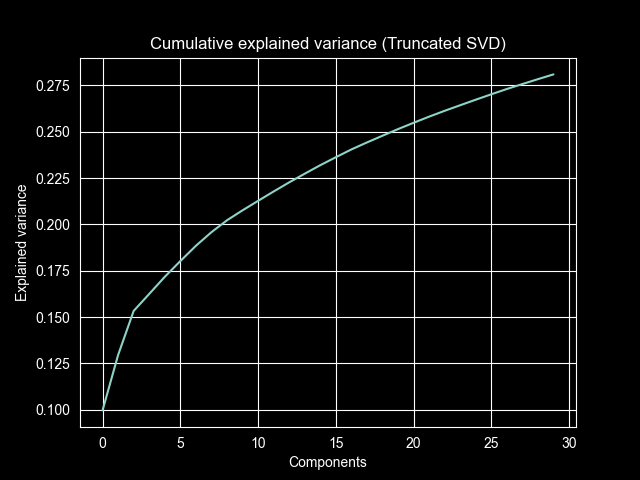

In [15]:
svd = TruncatedSVD(n_components=30, random_state=42)
X_svd = svd.fit_transform(train_matrix)

plt.figure()
plt.plot(np.cumsum(svd.explained_variance_ratio_))
plt.title("Cumulative explained variance (Truncated SVD)")
plt.xlabel("Components")
plt.ylabel("Explained variance")
plt.show()

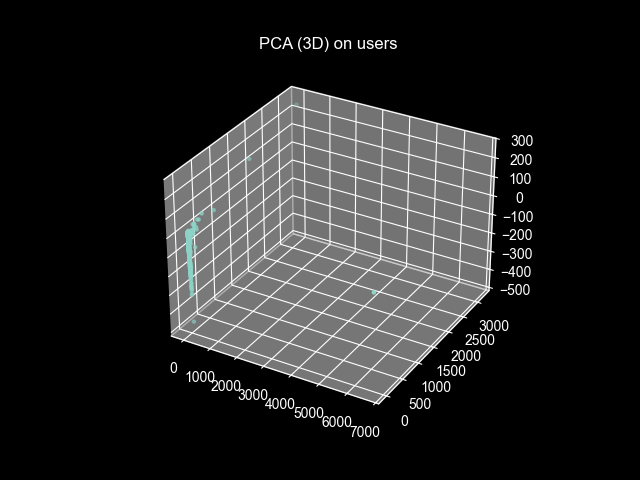

In [22]:
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_svd)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], s=5)
ax.set_title("PCA (3D) on users")
plt.show()

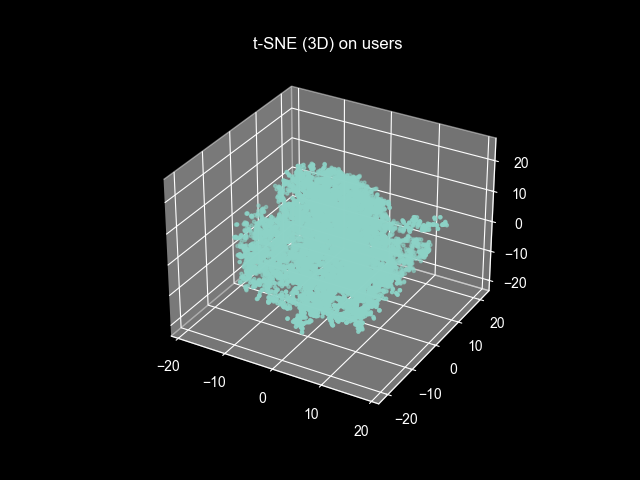

In [23]:
tsne = TSNE(n_components=3, random_state=42, n_jobs=8)
X_tsne = tsne.fit_transform(X_svd)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(X_tsne[:,0], X_tsne[:,1], X_tsne[:,2], s=5)
ax.set_title("t-SNE (3D) on users")
plt.show()

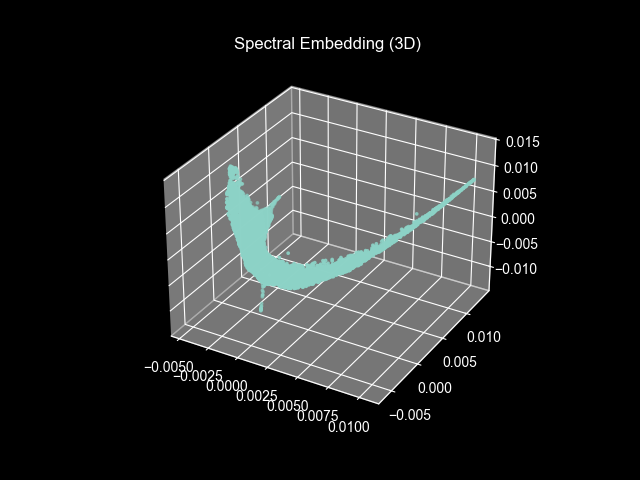

In [21]:
spec = SpectralEmbedding(
    n_components=3,
    affinity="nearest_neighbors",
    n_neighbors=10,
    random_state=42)

X_spec = spec.fit_transform(X_svd)

fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter(X_spec[:,0], X_spec[:,1], X_spec[:,2], s=3)
ax.set_title("Spectral Embedding (3D)")
plt.show()

# ALS

In [21]:
train_ui = train_matrix.tocsr().astype('float32')
val_ui = val_matrix.tocsr().astype('float32')
train_iu = train_ui.T.tocsr()

def objective(trial):
    factors = trial.suggest_int("factors", 32, 256)
    reg = trial.suggest_float("regularization", 0.01, 0.2, log=True)
    alpha = trial.suggest_float("alpha", 1.0, 20.0)

    model = AlternatingLeastSquares(
        factors=factors,
        regularization=reg,
        iterations=20,
        random_state=42
    )

    model.fit(train_matrix * alpha)

    metrics = ranking_metrics_at_k(model, train_ui, val_ui, 20, show_progress=False)
    trial.set_user_attr("map", metrics['map'])
    trial.set_user_attr("auc", metrics['auc'])
    trial.set_user_attr("precision", metrics['precision'])

    return metrics['ndcg']

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, show_progress_bar=True)

[I 2026-03-03 01:59:27,716] A new study created in memory with name: no-name-98a21b26-85ab-464e-9506-ba9294c92ca2


  0%|          | 0/30 [00:00<?, ?it/s]

C:\Users\Vlad\PycharmProjects\JupyterProject\.venv\Lib\site-packages\implicit\cpu\als.py:95: RuntimeWarning:

OpenBLAS is configured to use 16 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.



  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-03-03 01:59:52,052] Trial 0 finished with value: 0.0651609981756996 and parameters: {'factors': 188, 'regularization': 0.1315256620945584, 'alpha': 9.625747129544326}. Best is trial 0 with value: 0.0651609981756996.


...

[I 2026-03-03 02:17:28,451] Trial 27 finished with value: 0.06843638220391483 and parameters: {'factors': 169, 'regularization': 0.04841672798380683, 'alpha': 6.410184757140853}. Best is trial 26 with value: 0.07519955095146208.


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-03-03 02:20:28,867] Trial 28 finished with value: 0.06395517531225699 and parameters: {'factors': 202, 'regularization': 0.020869180143391685, 'alpha': 11.88850885243205}. Best is trial 26 with value: 0.07519955095146208.


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-03-03 02:20:53,194] Trial 29 finished with value: 0.06693730635154534 and parameters: {'factors': 179, 'regularization': 0.013708032447673449, 'alpha': 8.599529857137757}. Best is trial 26 with value: 0.07519955095146208.


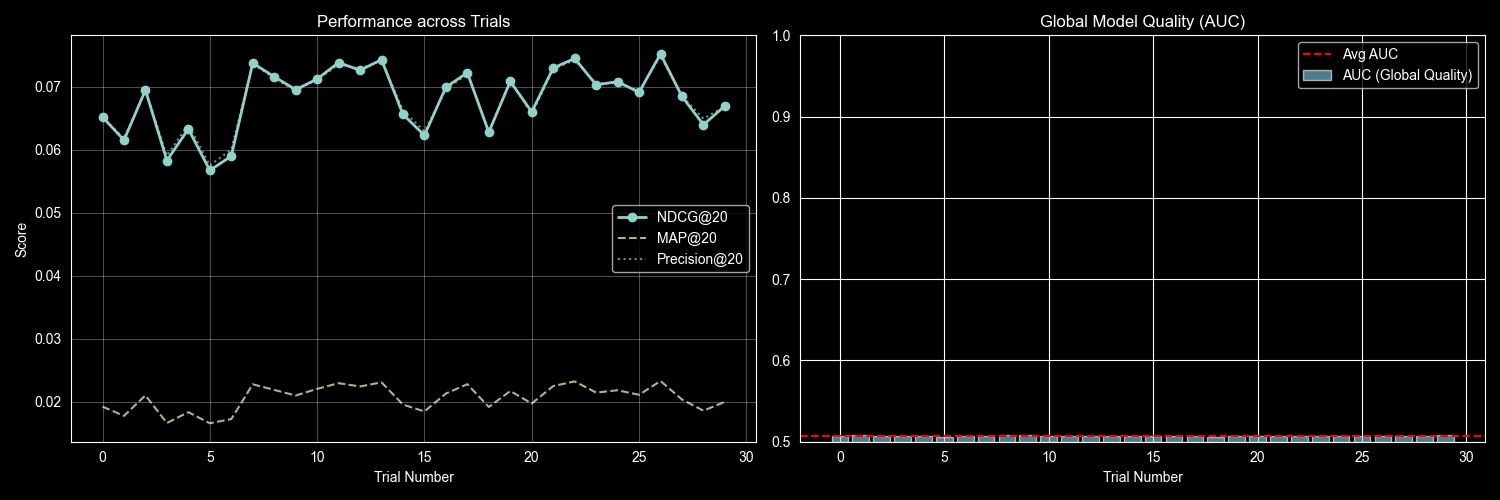

In [22]:
def plot_als_metrics(study):
    trials = study.trials
    valid_trials = [t for t in trials if t.value is not None]

    ndcgs = [t.value for t in valid_trials]
    maps = [t.user_attrs['map'] for t in valid_trials]
    aucs = [t.user_attrs['auc'] for t in valid_trials]
    precisions = [t.user_attrs['precision'] for t in valid_trials]

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    x = range(len(valid_trials))
    plt.plot(x, ndcgs, label='NDCG@20', marker='o', linewidth=2)
    plt.plot(x, maps, label='MAP@20', linestyle='--', alpha=0.7)
    plt.plot(x, precisions, label='Precision@20', linestyle=':', alpha=0.7)
    plt.title('Performance across Trials')
    plt.xlabel('Trial Number')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.bar(x, aucs, color='skyblue', alpha=0.6, label='AUC (Global Quality)')
    plt.axhline(y=np.mean(aucs), color='red', linestyle='--', label='Avg AUC')
    plt.title('Global Model Quality (AUC)')
    plt.xlabel('Trial Number')
    plt.ylim(0.5, 1.0)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_als_metrics(study)

In [24]:
final_als_train_matrix = train_matrix + val_matrix

best_als_params = study.best_params
final_als_model = AlternatingLeastSquares(**best_als_params,
                                          iterations=30,
                                          random_state=42)
final_als_model.fit(final_als_train_matrix * best_als_params['alpha'])

final_als_results = ranking_metrics_at_k(final_als_model, final_als_train_matrix, test_matrix, 20, show_progress=True)

print("\n--- ИТОГОВЫЕ МЕТРИКИ НА ТЕСТЕ ---")
for m, val in final_als_results.items():
    print(f"{m.upper():<10}: {val:.4f}")

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/9957 [00:00<?, ?it/s]


--- ИТОГОВЫЕ МЕТРИКИ НА ТЕСТЕ ---
PRECISION : 0.0713
MAP       : 0.0212
NDCG      : 0.0706
AUC       : 0.5070


In [47]:
import optuna.visualization as vis
import matplotlib.pyplot as plt

fig1 = vis.plot_optimization_history(study)
fig1.show()

fig2 = vis.plot_param_importances(study)
fig2.show()

fig3 = vis.plot_parallel_coordinate(study)
fig3.show()

print("\n" + "="*30)
print(f"ЛУЧШИЙ РЕЗУЛЬТАТ (NDCG@20): {study.best_value:.4f}")
print("ЛУЧШИЕ ПАРАМЕТРЫ:")
for key, value in study.best_params.items():
    print(f" - {key}: {value}")
print("="*30)


ЛУЧШИЙ РЕЗУЛЬТАТ (NDCG@20): 0.0752
ЛУЧШИЕ ПАРАМЕТРЫ:
 - factors: 173
 - regularization: 0.06247838089752494
 - alpha: 1.2696487957456881


In [2]:
import json
with open("best_als_params.json", "w") as f:
    json.dump(study.best_params, f)

fig1.write_html("als_optimisation_history.html")
fig2.write_html("als_param_importance.html")
fig3.write_html("als_parallel_coordinate.html")

NameError: name 'study' is not defined

# DeepFM

In [15]:
def prepare_yambda_for_recbole(df, folder='dataset/yambda'):
    if not os.path.exists(folder):
        os.makedirs(folder)

    inter_df = df[['uid', 'item_id', 'event_score', 'timestamp']].copy()

    inter_df.columns = ['user_id:token', 'item_id:token', 'label:float', 'timestamp:float']

    file_path = os.path.join(folder, 'yambda.inter')
    inter_df.to_csv(file_path, sep='\t', index=False)
    print(f"Dataset prepared at {file_path}")

prepare_yambda_for_recbole(multi_event)

Dataset prepared at dataset/yambda\yambda.inter


In [2]:
import optuna
from recbole.config import Config
from recbole.data import create_dataset, data_preparation
from recbole.utils import init_seed, get_model, get_trainer

def objective(trial):
    embedding_size = trial.suggest_int('embedding_size', 32, 128, step=32)
    learning_rate = trial.suggest_categorical('learning_rate', [0.01, 0.005, 0.001, 0.0005, 0.0001])
    dropout = trial.suggest_float('dropout_prob', 0.0, 0.5, step=0.1)
    mlp_hidden = trial.suggest_categorical('mlp_hidden', ['[64,64,64]','[128,128,128]','[256,256,256]','[512,512,512]'])

    config_dict = {
        'model': 'DeepFM',
        'dataset': 'yambda',
        'data_path': 'dataset/',
        'checkpoint_dir': 'saved/',
        'device': 'cuda:0',

        'learning_rate': learning_rate,
        'dropout_prob': dropout,
        'mlp_hidden_size': eval(mlp_hidden),
        'embedding_size': embedding_size,

        'epochs': 10,
        'train_batch_size': 4096,
        'eval_step': 1,
        'stopping_step': 2,
        'train_neg_sample_num': 1,
        'state': 'ERROR',

        'worker_num': 0,
        'persistent_workers': False,

        'load_col': {'inter': ['user_id', 'item_id', 'label', 'timestamp']},
        'LABEL_FIELD': 'label',
        'threshold': {'label': 0.1},

        'eval_args': {
            'split': {'RS': [0.8, 0.1, 0.1]},
            'group_by': 'user',
            'order': 'TO',
            'mode': 'full'
        },

        'metrics': ['MAP', 'Precision', 'NDCG'],
        'topk': [20],
        'valid_metric': 'NDCG@20',
    }

    try:
        config = Config(model='DeepFM', dataset='yambda', config_dict=config_dict)
        init_seed(config['seed'], config['reproducibility'])

        dataset = create_dataset(config)
        train_data, valid_data, test_data = data_preparation(config, dataset)

        model = get_model(config['model'])(config, train_data.dataset)
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model.to(device)

        trainer = get_trainer(config['trainer'], config['model'])(config, model)

        best_valid_score, _ = trainer.fit(train_data, valid_data, show_progress=True)
        return best_valid_score
    except Exception as e:
        print(f"Trial failed: {e}")
        return 0.0

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=5)

[I 2026-03-02 22:41:19,628] A new study created in memory with name: no-name-16a76cab-97e6-4879-8f6a-5d2f5f77fc52
C:\Users\Vlad\PycharmProjects\JupyterProject\.venv\Lib\site-packages\recbole\data\dataset\dataset.py:648: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  feat[field].fillna(value=0, inplace=True)
C:\Users\Vlad\PycharmProjec

Training on: cuda


Train     0:   0%|                                                         | 0/8532 [00:00<?, ?it/s]C:\Users\Vlad\PycharmProjects\JupyterProject\.venv\Lib\site-packages\recbole\trainer\trainer.py:235: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler(enabled=self.enable_scaler)
Evaluate   : 100%|██████████████████████| 9957/9957 [04:17<00:00, 38.73it/s, GPU RAM: 0.45 G/8.00 G]
[I 2026-03-02 23:09:42,990] Trial 0 finished with value: 0.019 and parameters: {'embedding_size': 128, 'learning_rate': 0.005, 'dropout_prob': 0.1, 'mlp_hidden': '[64,64,64]'}. Best is trial 0 with value: 0.019.
C:\Users\Vlad\PycharmProjects\JupyterProject\.venv\Lib\site-packages\recbole\data\dataset\dataset.py:648: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or

Training on: cuda


Train     0:   0%|                                                         | 0/8532 [00:00<?, ?it/s]C:\Users\Vlad\PycharmProjects\JupyterProject\.venv\Lib\site-packages\recbole\trainer\trainer.py:235: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler(enabled=self.enable_scaler)
Evaluate   : 100%|██████████████████████| 9957/9957 [04:14<00:00, 39.18it/s, GPU RAM: 0.45 G/8.00 G]
[I 2026-03-02 23:36:30,731] Trial 1 finished with value: 0.0021 and parameters: {'embedding_size': 32, 'learning_rate': 0.01, 'dropout_prob': 0.0, 'mlp_hidden': '[128,128,128]'}. Best is trial 0 with value: 0.019.
C:\Users\Vlad\PycharmProjects\JupyterProject\.venv\Lib\site-packages\recbole\data\dataset\dataset.py:648: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame 

...

Train     0:   0%|                                                         | 0/8532 [00:00<?, ?it/s]C:\Users\Vlad\PycharmProjects\JupyterProject\.venv\Lib\site-packages\recbole\trainer\trainer.py:235: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler(enabled=self.enable_scaler)
Evaluate   : 100%|██████████████████████| 9957/9957 [04:22<00:00, 38.00it/s, GPU RAM: 0.45 G/8.00 G]
[I 2026-03-03 00:04:28,168] Trial 2 finished with value: 0.0045 and parameters: {'embedding_size': 96, 'learning_rate': 0.01, 'dropout_prob': 0.4, 'mlp_hidden': '[256,256,256]'}. Best is trial 0 with value: 0.019.
C:\Users\Vlad\PycharmProjects\JupyterProject\.venv\Lib\site-packages\recbole\data\dataset\dataset.py:648: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame 

Training on: cuda


Train     0:   0%|                                                         | 0/8532 [00:00<?, ?it/s]C:\Users\Vlad\PycharmProjects\JupyterProject\.venv\Lib\site-packages\recbole\trainer\trainer.py:235: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler(enabled=self.enable_scaler)
Evaluate   : 100%|██████████████████████| 9957/9957 [04:16<00:00, 38.79it/s, GPU RAM: 0.45 G/8.00 G]
[I 2026-03-03 01:07:51,654] Trial 3 finished with value: 0.048 and parameters: {'embedding_size': 128, 'learning_rate': 0.0005, 'dropout_prob': 0.30000000000000004, 'mlp_hidden': '[128,128,128]'}. Best is trial 3 with value: 0.048.
C:\Users\Vlad\PycharmProjects\JupyterProject\.venv\Lib\site-packages\recbole\data\dataset\dataset.py:648: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the o

Training on: cuda


Train     0:   0%|                                                         | 0/8532 [00:00<?, ?it/s]C:\Users\Vlad\PycharmProjects\JupyterProject\.venv\Lib\site-packages\recbole\trainer\trainer.py:235: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler(enabled=self.enable_scaler)
Evaluate   : 100%|██████████████████████| 9957/9957 [04:20<00:00, 38.27it/s, GPU RAM: 0.45 G/8.00 G]
[I 2026-03-03 01:35:45,853] Trial 4 finished with value: 0.0095 and parameters: {'embedding_size': 32, 'learning_rate': 0.005, 'dropout_prob': 0.0, 'mlp_hidden': '[256,256,256]'}. Best is trial 3 with value: 0.048.


In [3]:
import optuna.visualization as vis
import matplotlib.pyplot as plt

fig1 = vis.plot_optimization_history(study)
fig1.show()

fig2 = vis.plot_param_importances(study)
fig2.show()

fig3 = vis.plot_parallel_coordinate(study)
fig3.show()

print("\n" + "="*30)
print(f"ЛУЧШИЙ РЕЗУЛЬТАТ (NDCG@20): {study.best_value:.4f}")
print("ЛУЧШИЕ ПАРАМЕТРЫ:")
for key, value in study.best_params.items():
    print(f" - {key}: {value}")
print("="*30)


ЛУЧШИЙ РЕЗУЛЬТАТ (NDCG@20): 0.0480
ЛУЧШИЕ ПАРАМЕТРЫ:
 - embedding_size: 128
 - learning_rate: 0.0005
 - dropout_prob: 0.30000000000000004
 - mlp_hidden: [128,128,128]


In [5]:
import json
with open("best_deepfm_params.json", "w") as f:
    json.dump(study.best_params, f)

fig1.write_html("optimisation_history.html")
fig2.write_html("param_importance.html")
fig3.write_html("parallel_coordinate.html")

In [26]:
with open("best_deepfm_params.json", "r") as f:
    best_deepfm_params = json.load(f)

In [32]:
final_config_dict = {
    'model': 'DeepFM',
    'dataset': 'yambda',
    'data_path': 'dataset/',
    'device': 'cuda:0',
    'load_col': {'inter': ['user_id', 'item_id', 'label', 'timestamp']},
    'LABEL_FIELD': 'label',
    'threshold': {'label': 0.1},

    'learning_rate': best_deepfm_params['learning_rate'],
    'dropout_prob': best_deepfm_params['dropout_prob'],
    'mlp_hidden_size': eval(best_deepfm_params['mlp_hidden']),
    'embedding_size': best_deepfm_params['embedding_size'],

    'epochs': 30,
    'train_batch_size': 4096,
    'train_neg_sample_num': 1,
    'worker_num': 0,
    'stopping_step': 5,

    'eval_args': {
        'split': {'RS': [0.8, 0.1, 0.1]},
        'group_by': 'user',
        'order': 'TO',
        'mode': 'full'
    },
    'metrics': ['MAP', 'Precision', 'NDCG'],
    'topk': [20],
    'valid_metric': 'NDCG@20',
}

config = Config(model='DeepFM', dataset='yambda', config_dict=final_config_dict)
init_seed(config['seed'], config['reproducibility'])
dataset = create_dataset(config)
train_data, valid_data, test_data = data_preparation(config, dataset)

model = get_model(config['model'])(config, train_data.dataset).to(config['device'])
trainer = get_trainer(config['trainer'], config['model'])(config, model)

trainer.fit(train_data, valid_data, show_progress=True)
test_results = trainer.evaluate(test_data, load_best_model=False)
deepfm_results = {
    'map': test_results['map@20'],
    'ndcg': test_results['ndcg@20'],
    'precision': test_results['precision@20']
}

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

comparison_data = {
    'Metric': ['MAP@20', 'Precision@20', 'NDCG@20'],
    'DeepFM (Neural)': [
        deepfm_results['map'],
        deepfm_results['precision'],
        deepfm_results['ndcg']
    ],
    'ALS (Baseline)': [
        final_als_results['map'],
        final_als_results['precision'],
        final_als_results['ndcg']
    ]
}

df_compare = pd.DataFrame(comparison_data).set_index('Metric')
df_compare['Gain %'] = ((df_compare['ALS (Baseline)'] - df_compare['DeepFM (Neural)']) / df_compare['ALS (Baseline)'] * 100).round(2)

print("=== СРАВНЕНИЕ МОДЕЛЕЙ НА ТЕСТЕ ===")
print(df_compare)

=== СРАВНЕНИЕ МОДЕЛЕЙ НА ТЕСТЕ ===
              DeepFM (Neural)  ALS (Baseline)  Gain %
Metric                                               
MAP@20                 0.0145        0.021179   31.54
Precision@20           0.0264        0.071263   62.95
NDCG@20                0.0332        0.070555   52.94


# BPR

In [1]:
def prepare_yambda_for_recbole(df, folder='dataset/yambda'):
    if not os.path.exists(folder):
        os.makedirs(folder)

    inter_df = df[['uid', 'item_id', 'event_score', 'timestamp']].copy()

    inter_df.columns = ['user_id:token', 'item_id:token', 'label:float', 'timestamp:float']

    file_path = os.path.join(folder, 'yambda.inter')
    inter_df.to_csv(file_path, sep='\t', index=False)
    print(f"Dataset prepared at {file_path}")

prepare_yambda_for_recbole(multi_event)

NameError: name 'multi_event' is not defined

In [2]:
import optuna
from recbole.config import Config
from recbole.data import create_dataset, data_preparation
from recbole.utils import init_seed, get_model, get_trainer

base_config_dict = {
    'model': 'BPR',
    'dataset': 'yambda',
    'data_path': 'dataset/',
    'device': 'cuda:0',
    'load_col': {'inter': ['user_id', 'item_id', 'label', 'timestamp']},
    'LABEL_FIELD': 'label',
    'threshold': {'label': 0.1},

    'epochs': 10,
    'train_batch_size': 4096,
    'train_neg_sample_num': 1,
    'worker_num': 0,

    'eval_args': {
        'split': {'RS': [0.8, 0.1, 0.1]},
        'group_by': 'user',
        'order': 'TO',
        'mode': 'uni100'
    },
    'metrics': ['NDCG', 'PRECISION', 'MAP'],
    'topk': [20],
    'valid_metric': 'NDCG@20',
}

config = Config(model='BPR', dataset='yambda', config_dict=base_config_dict)
init_seed(42, True)

In [ ]:
dataset = create_dataset(config)
train_data, valid_data, test_data = data_preparation(config, dataset)

In [5]:
def objective(trial):
    params = {
        'embedding_size': trial.suggest_int('embedding_size', 32, 128, step=32),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True),
    }

    try:
        current_config = Config(model='BPR', dataset='yambda', config_dict={**base_config_dict, **params})
        model = get_model('BPR')(current_config, train_data.dataset).to('cuda:0')
        trainer = get_trainer('BPR', 'BPR')(current_config, model)
        print("started")
        best_valid_score, _ = trainer.fit(train_data, valid_data, show_progress=True)
        return best_valid_score
    except Exception as e:
        return 0.0

study_bpr = optuna.create_study(direction='maximize')
study_bpr.optimize(objective, n_trials=10)

[I 2026-03-04 01:23:23,216] A new study created in memory with name: no-name-8160f958-57fd-48ca-9bc3-73075adc8116


started


Train     0:   0%|                                                         | 0/8532 [00:00<?, ?it/s]C:\Users\Vlad\PycharmProjects\JupyterProject\.venv\Lib\site-packages\recbole\trainer\trainer.py:235: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler(enabled=self.enable_scaler)
Evaluate   : 100%|██████████████████████| 9957/9957 [01:46<00:00, 93.52it/s, GPU RAM: 0.21 G/8.00 G]
[I 2026-03-04 01:53:03,937] Trial 0 finished with value: 0.7455 and parameters: {'embedding_size': 64, 'learning_rate': 0.0012677478041004248}. Best is trial 0 with value: 0.7455.


started


Evaluate   : 100%|██████████████████████| 9957/9957 [01:50<00:00, 90.31it/s, GPU RAM: 0.32 G/8.00 G]
[I 2026-03-04 02:22:45,799] Trial 1 finished with value: 0.7434 and parameters: {'embedding_size': 64, 'learning_rate': 0.0007394765555726321}. Best is trial 0 with value: 0.7455.


...

Evaluate   : 100%|██████████████████████| 9957/9957 [01:57<00:00, 84.57it/s, GPU RAM: 0.92 G/8.00 G]
[I 2026-03-04 05:35:48,837] Trial 7 finished with value: 0.7518 and parameters: {'embedding_size': 128, 'learning_rate': 0.000379009480838842}. Best is trial 2 with value: 0.7526.


started


Evaluate   : 100%|██████████████████████| 9957/9957 [01:46<00:00, 93.62it/s, GPU RAM: 0.92 G/8.00 G]
[I 2026-03-04 06:05:18,063] Trial 8 finished with value: 0.7478 and parameters: {'embedding_size': 64, 'learning_rate': 0.0011241126117058245}. Best is trial 2 with value: 0.7526.


started


Evaluate   : 100%|██████████████████████| 9957/9957 [02:01<00:00, 81.82it/s, GPU RAM: 0.92 G/8.00 G]
[I 2026-03-04 06:39:15,210] Trial 9 finished with value: 0.6762 and parameters: {'embedding_size': 128, 'learning_rate': 0.0001291783347107846}. Best is trial 2 with value: 0.7526.


In [8]:
import optuna.visualization as vis
import matplotlib.pyplot as plt

fig1 = vis.plot_optimization_history(study_bpr)
fig1.show()

fig2 = vis.plot_param_importances(study_bpr)
fig2.show()

fig3 = vis.plot_parallel_coordinate(study_bpr)
fig3.show()

print("\n" + "="*30)
print(f"ЛУЧШИЙ РЕЗУЛЬТАТ (NDCG@20): {study_bpr.best_value:.4f}")
print("ЛУЧШИЕ ПАРАМЕТРЫ:")
for key, value in study_bpr.best_params.items():
    print(f" - {key}: {value}")
print("="*30)


ЛУЧШИЙ РЕЗУЛЬТАТ (NDCG@20): 0.7526
ЛУЧШИЕ ПАРАМЕТРЫ:
 - embedding_size: 128
 - learning_rate: 0.0003834013351473748


In [ ]:
import json
with open("best_bpr_params.json", "w") as f:
    json.dump(study_bpr.best_params, f)

fig1.write_html("bpr_optimisation_history.html")
fig2.write_html("bpr_param_importance.html")
fig3.write_html("bpr_parallel_coordinate.html")

In [ ]:
best_bpr_params = {
    'embedding_size': 128,
    'learning_rate': 0.0003834013351473748
}

final_bpr_config_dict = base_config_dict.copy()
final_bpr_config_dict.update(best_bpr_params)
final_bpr_config_dict['epochs'] = 20

final_bpr_config = Config(model='BPR', dataset='yambda', config_dict=final_bpr_config_dict)
model = get_model('BPR')(final_bpr_config, train_data.dataset).to('cuda:0')
trainer = get_trainer('BPR', 'BPR')(final_bpr_config, model)

trainer.fit(train_data, valid_data, show_progress=True)
bpr_test_results = trainer.evaluate(test_data, load_best_model=False)

bpr_results = {
    'ndcg': bpr_test_results.get('ndcg@20', 0),
    'map': bpr_test_results.get('map@20', 0),
    'precision': bpr_test_results.get('precision@20', 0)
}


       ИТОГОВОЕ СРАВНЕНИЕ ТРЕХ ПОДХОДОВ
              ALS (Static)  DeepFM (Neural)  BPR (Bayesian)
Metric                                                     
MAP@20              0.0212           0.0145          0.8079
Precision@20        0.0713           0.0264          0.8007
NDCG@20             0.0706           0.0332          0.8758


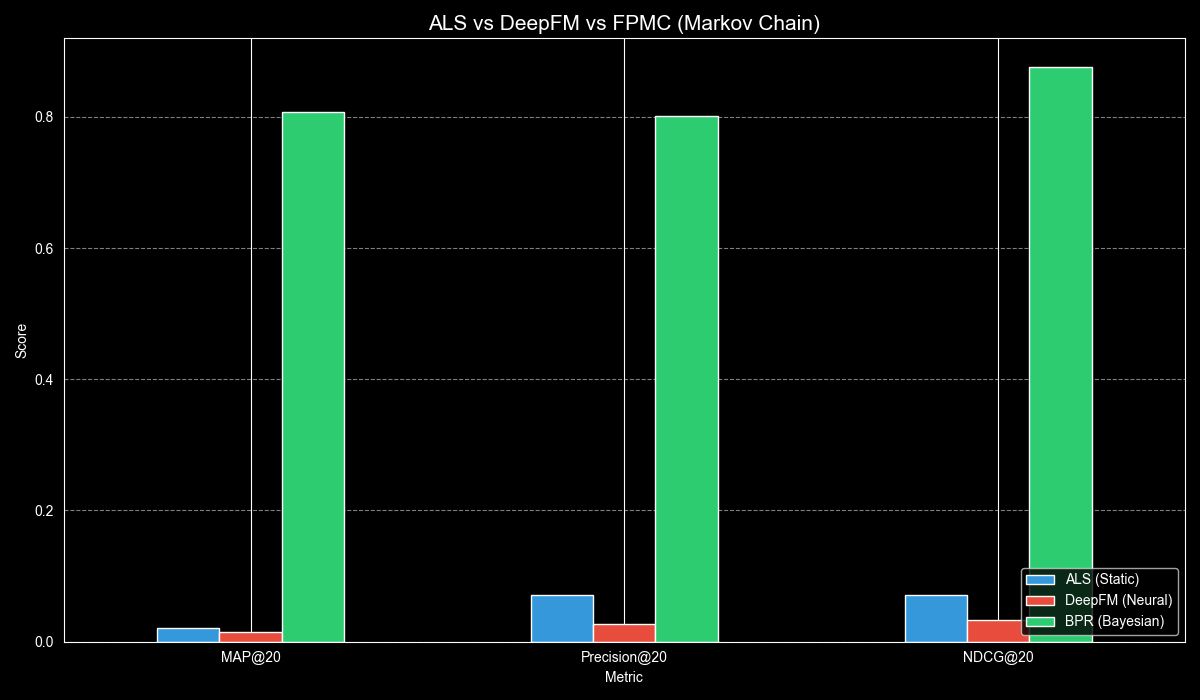

In [34]:
comparison_data = {
    'Metric': ['MAP@20', 'Precision@20', 'NDCG@20'],
    'ALS (Static)': [
        final_als_results.get('map', 0),
        final_als_results.get('precision', 0),
        final_als_results.get('ndcg', 0),
    ],
    'DeepFM (Neural)': [
        deepfm_results.get('map', 0),
        deepfm_results.get('precision', 0),
        deepfm_results.get('ndcg', 0),
    ],
    'BPR (Bayesian)': [
        bpr_results['map'],
        bpr_results['precision'],
        bpr_results['ndcg'],
    ]
}

df_final = pd.DataFrame(comparison_data).set_index('Metric')

print("\n" + "="*50)
print("       ИТОГОВОЕ СРАВНЕНИЕ ТРЕХ ПОДХОДОВ")
print("="*50)
print(df_final.round(4))
print("="*50)

ax = df_final.plot(kind='bar', figsize=(12, 7), rot=0,
                   color=['#3498db', '#e74c3c', '#2ecc71'])
plt.title('ALS vs DeepFM vs FPMC (Markov Chain)', fontsize=15)
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Почему такое различие в метриках? (ВАЖНО)

ALS и DeepFM я обучал на mode: 'full', а BPR на 'mode': 'uni100', соответственно в режиме full модель должна найти подходящий трек среди всего каталога, который составляет 148000 кандидатов, а в режиме uni100 задача упростилась до выбора 1 правильного трека из всего 101 кандидата, отсюда и разница в метриках.